# Canada Job Market Analysis

## 1. Project Overview

Data source: Statistics Canada, Table 14-10-0441-01

This project analyzes job vacancy rates and average offered hourly wages across selected Canadian regions over time.

## 2. Data Loading and Initial Inspection

In [189]:
import pandas as pd

df = pd.read_csv('14100441.csv')
df

,REF_DATE,GEO,DGUID,Statistics,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,2015-01,Canada,2021A000011124,Job vacancies,Number,223,units,0,v1568395842,1.1,408405.00,E,NaN,NaN,0
1,2015-01,Canada,2021A000011124,Payroll employees,Number,223,units,0,v1568395843,1.3,14934365.00,D,NaN,NaN,0
2,2015-01,Canada,2021A000011124,Job vacancy rate,Percent,239,units,0,v1568395844,1.4,2.70,E,NaN,NaN,1
3,2015-01,Canada,2021A000011124,Average offered hourly wage,Dollars,81,units,0,v1568395845,1.5,19.10,D,NaN,NaN,2
4,2015-01,Newfoundland and Labrador,2021A000210,Job vacancies,Number,223,units,0,v1568395846,2.1,NaN,F,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14271,2026-01,Nunavut,2021A000262,Average offered hourly wage,Dollars,81,units,0,v1568395897,14.5,36.05,A,NaN,NaN,2
14272,2026-01,Nunavut,2021S05006210,Job vacancies,Number,223,units,0,v1568396142,90.1,450.00,D,NaN,NaN,0
14273,2026-01,Nunavut,2021S05006210,Payroll employees,Number,223,units,0,v1568396143,90.3,17815.00,A,NaN,NaN,0
14274,2026-01,Nunavut,2021S05006210,Job vacancy rate,Percent,239,units,0,v1568396144,90.4,2.50,C,NaN,NaN,1


In [190]:
df.head()

,REF_DATE,GEO,DGUID,Statistics,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,2015-01,Canada,2021A000011124,Job vacancies,Number,223,units,0,v1568395842,1.1,408405.0,E,NaN,NaN,0
1,2015-01,Canada,2021A000011124,Payroll employees,Number,223,units,0,v1568395843,1.3,14934365.0,D,NaN,NaN,0
2,2015-01,Canada,2021A000011124,Job vacancy rate,Percent,239,units,0,v1568395844,1.4,2.7,E,NaN,NaN,1
3,2015-01,Canada,2021A000011124,Average offered hourly wage,Dollars,81,units,0,v1568395845,1.5,19.1,D,NaN,NaN,2
4,2015-01,Newfoundland and Labrador,2021A000210,Job vacancies,Number,223,units,0,v1568395846,2.1,NaN,F,NaN,NaN,0


In [191]:
df.shape

(14276, 15)

In [192]:
df.columns.tolist()

['REF_DATE',
 'GEO',
 'DGUID',
 'Statistics',
 'UOM',
 'UOM_ID',
 'SCALAR_FACTOR',
 'SCALAR_ID',
 'VECTOR',
 'COORDINATE',
 'VALUE',
 'STATUS',
 'SYMBOL',
 'TERMINATED',
 'DECIMALS']

In [193]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14276 entries, 0 to 14275
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   REF_DATE       14276 non-null  object 
 1   GEO            14276 non-null  object 
 2   DGUID          13072 non-null  object 
 3   Statistics     14276 non-null  object 
 4   UOM            14276 non-null  object 
 5   UOM_ID         14276 non-null  int64  
 6   SCALAR_FACTOR  14276 non-null  object 
 7   SCALAR_ID      14276 non-null  int64  
 8   VECTOR         14276 non-null  object 
 9   COORDINATE     14276 non-null  float64
 10  VALUE          14184 non-null  float64
 11  STATUS         14276 non-null  object 
 12  SYMBOL         0 non-null      float64
 13  TERMINATED     0 non-null      float64
 14  DECIMALS       14276 non-null  int64  
dtypes: float64(4), int64(3), object(8)
memory usage: 1.6+ MB


In [194]:
df["Statistics"].value_counts(dropna=False)

,count
Statistics,
Job vacancies,3569
Payroll employees,3569
Job vacancy rate,3569
Average offered hourly wage,3569


In [195]:
df["UOM"].value_counts(dropna=False)

,count
UOM,
Number,7138
Percent,3569
Dollars,3569


In [196]:
df["STATUS"].value_counts(dropna=False)

,count
STATUS,
A,7839
B,4434
C,1450
D,268
E,193
F,92


In [197]:
indicator_units = (
    df[["Statistics", "UOM", "SCALAR_FACTOR", "DECIMALS"]]
    .drop_duplicates()
    .sort_values("Statistics")
)

indicator_units

,Statistics,UOM,SCALAR_FACTOR,DECIMALS
3,Average offered hourly wage,Dollars,units,2
0,Job vacancies,Number,units,0
2,Job vacancy rate,Percent,units,1
1,Payroll employees,Number,units,0


In [198]:
df["GEO"].nunique()

79

In [199]:
df.loc[
    df["GEO"].str.contains(
        "Ottawa|Toronto|Montréal",
        case=False,
        na=False
    ),
    "GEO"
].drop_duplicates()

,GEO
108,"Montréal, Quebec"
148,"Ottawa, Ontario"
160,"Toronto, Ontario"


In [200]:
df.loc[
    df["GEO"].isin(["Canada", "Ontario"]),
    "GEO"
].drop_duplicates()

,GEO
0,Canada
144,Ontario


In [201]:
target_regions = [
    "Canada",
    "Ontario",
    "Ottawa, Ontario",
    "Toronto, Ontario",
    "Montréal, Quebec"
]

df[
    df["GEO"].isin(target_regions)
][
    ["REF_DATE", "GEO", "Statistics", "UOM", "VALUE", "STATUS"]
].head(20)

,REF_DATE,GEO,Statistics,UOM,VALUE,STATUS
0,2015-01,Canada,Job vacancies,Number,408405.00,E
1,2015-01,Canada,Payroll employees,Number,14934365.00,D
2,2015-01,Canada,Job vacancy rate,Percent,2.70,E
3,2015-01,Canada,Average offered hourly wage,Dollars,19.10,D
108,2015-01,"Montréal, Quebec",Job vacancies,Number,21415.00,E
109,2015-01,"Montréal, Quebec",Payroll employees,Number,1002885.00,E
110,2015-01,"Montréal, Quebec",Job vacancy rate,Percent,2.10,E
111,2015-01,"Montréal, Quebec",Average offered hourly wage,Dollars,22.05,E
144,2015-01,Ontario,Job vacancies,Number,153005.00,E
145,2015-01,Ontario,Payroll employees,Number,5712790.00,D


In [202]:
status_missing = pd.crosstab(
    df["STATUS"],
    df["VALUE"].isna(),
    rownames=["STATUS"],
    colnames=["VALUE is missing"]
)

status_missing

VALUE is missing,False,True
STATUS,,
A,7839,0
B,4434,0
C,1450,0
D,268,0
E,193,0
F,0,92


In [203]:
missing_by_indicator = (
    df[df["VALUE"].isna()]
    ["Statistics"]
    .value_counts()
)

missing_by_indicator

,count
Statistics,
Job vacancy rate,39
Job vacancies,36
Average offered hourly wage,9
Payroll employees,8


In [204]:
df[
    df["STATUS"].isin(["E", "F"])
][
    ["REF_DATE", "GEO", "Statistics", "VALUE", "STATUS"]
].head(20)

,REF_DATE,GEO,Statistics,VALUE,STATUS
0,2015-01,Canada,Job vacancies,408405.0,E
2,2015-01,Canada,Job vacancy rate,2.7,E
4,2015-01,Newfoundland and Labrador,Job vacancies,NaN,F
5,2015-01,Newfoundland and Labrador,Payroll employees,194435.0,E
6,2015-01,Newfoundland and Labrador,Job vacancy rate,NaN,F
7,2015-01,Newfoundland and Labrador,Average offered hourly wage,19.3,E
8,2015-01,"Avalon Peninsula, Newfoundland and Labrador",Job vacancies,NaN,F
9,2015-01,"Avalon Peninsula, Newfoundland and Labrador",Payroll employees,NaN,F
10,2015-01,"Avalon Peninsula, Newfoundland and Labrador",Job vacancy rate,NaN,F
11,2015-01,"Avalon Peninsula, Newfoundland and Labrador",Average offered hourly wage,NaN,F


In [205]:
df["REF_DATE"].str[-2:].value_counts().sort_index()

,count
REF_DATE,
01,3984
04,3320
07,3320
10,3652


## 3. Data Cleaning and Geographic Identifiers

In [206]:
geo_dguid_counts = (
    df.groupby("GEO")["DGUID"]
    .nunique()
    .sort_values(ascending=False)
)

geo_dguid_counts[geo_dguid_counts > 1]

,DGUID
GEO,
Prince Edward Island,2
Yukon,2
Northwest Territories,2
Nunavut,2


In [207]:
problem_geos = geo_dguid_counts[
    geo_dguid_counts > 1
].index

df.loc[
    df["GEO"].isin(problem_geos),
    ["GEO", "DGUID"]
].drop_duplicates().sort_values(["GEO", "DGUID"])

,GEO,DGUID
316,Northwest Territories,2021A000261
320,Northwest Territories,2021S05006110
324,Nunavut,2021A000262
328,Nunavut,2021S05006210
20,Prince Edward Island,2021A000211
24,Prince Edward Island,2021S05001110
308,Yukon,2021A000260
312,Yukon,2021S05006010


In [208]:
full_core_columns = [
    "REF_DATE",
    "GEO",
    "DGUID",
    "Statistics",
    "UOM",
    "VALUE",
    "STATUS"
]

full_clean_df = df.loc[:, full_core_columns].copy().reset_index(drop=True)

In [209]:
full_clean_df['DATE'] = pd.to_datetime(
    full_clean_df['REF_DATE'],
    format='%Y-%m'
)

full_clean_df['QUARTER'] = full_clean_df['DATE'].dt.to_period('Q')

In [210]:
full_clean_df.duplicated(
    subset=["QUARTER", "GEO", "DGUID", "Statistics"]
).sum()

np.int64(0)

In [211]:
full_clean_df.shape

(14276, 9)

In [212]:
full_clean_df.head()

,REF_DATE,GEO,DGUID,Statistics,UOM,VALUE,STATUS,DATE,QUARTER
0,2015-01,Canada,2021A000011124,Job vacancies,Number,408405.0,E,2015-01-01,2015Q1
1,2015-01,Canada,2021A000011124,Payroll employees,Number,14934365.0,D,2015-01-01,2015Q1
2,2015-01,Canada,2021A000011124,Job vacancy rate,Percent,2.7,E,2015-01-01,2015Q1
3,2015-01,Canada,2021A000011124,Average offered hourly wage,Dollars,19.1,D,2015-01-01,2015Q1
4,2015-01,Newfoundland and Labrador,2021A000210,Job vacancies,Number,NaN,F,2015-01-01,2015Q1


## 4. Five-Region Comparison Dataset

In [213]:
target_regions = [
    'Canada',
    'Ontario',
    'Ottawa, Ontario',
    'Toronto, Ontario',
    'Montréal, Quebec'
]

comparison_columns = [
    'REF_DATE',
    "GEO",
    "Statistics",
    "UOM",
    "VALUE",
    "STATUS",
    "DATE",
    'QUARTER'
]

comparison_df = full_clean_df.loc[
    full_clean_df['GEO'].isin(target_regions),
    comparison_columns
].copy().reset_index(drop=True)

In [214]:
comparison_df.shape

(860, 8)

In [215]:
comparison_df.duplicated(subset=['QUARTER', 'GEO', 'Statistics']).sum()

np.int64(0)

### Data Reshaping

The comparison dataset was converted from long format to wide format using `pivot()`. Each row now represents one quarter and one geography, while the four labour-market indicators are stored in separate columns.

In [216]:
comparison_wide_df = comparison_df.pivot(
    index = ['DATE', 'QUARTER', 'GEO'],
    columns = 'Statistics',
    values = 'VALUE'
).reset_index()

In [217]:
comparison_wide_df = comparison_wide_df.rename(columns={
    'Average offered hourly wage': 'average_offered_hourly_wage',
    'Job vacancies': 'job_vacancies',
    'Job vacancy rate': 'job_vacancy_rate',
    'Payroll employees': 'payroll_employees'
})

In [218]:
comparison_wide_df.columns.name = None

In [219]:
comparison_wide_df.shape

(215, 7)

In [220]:
comparison_wide_df['GEO'].nunique()

5

In [221]:
comparison_wide_df['QUARTER'].nunique()

43

In [222]:
comparison_wide_df.isna().sum()

,0
DATE,0
QUARTER,0
GEO,0
average_offered_hourly_wage,0
job_vacancies,1
job_vacancy_rate,1
payroll_employees,1


### Missing-Value Treatment

The comparison dataset contains three missing observations. These observations belong to Ottawa, Ontario in 2015Q1 and have STATUS = F.

They are retained as missing values rather than replaced with zero because missing or unpublished data does not imply that the true value was zero.

In [223]:
comparison_wide_df.duplicated(subset=['QUARTER', 'GEO']).sum()

np.int64(0)

## 5. Latest-Quarter Snapshot

In [224]:
latest_quarter = comparison_wide_df['QUARTER'].max()

latest_snapshot = comparison_wide_df.loc[
    comparison_wide_df['QUARTER'] == latest_quarter
    ].copy().sort_values('job_vacancy_rate', ascending=False).reset_index(drop=True)

In [225]:
latest_snapshot

,DATE,QUARTER,GEO,average_offered_hourly_wage,job_vacancies,job_vacancy_rate,payroll_employees
0,2026-01-01,2026Q1,Canada,29.55,473035.0,2.7,17302245.0
1,2026-01-01,2026Q1,Ontario,30.70,163655.0,2.4,6715050.0
2,2026-01-01,2026Q1,"Montréal, Quebec",32.35,30165.0,2.3,1253545.0
3,2026-01-01,2026Q1,"Toronto, Ontario",32.80,78915.0,2.3,3428370.0
4,2026-01-01,2026Q1,"Ottawa, Ontario",31.30,14330.0,2.1,673560.0


## 6. Ottawa Labour Market Analysis

In [226]:
ottawa_df = comparison_wide_df.loc[
    comparison_wide_df['GEO'] == 'Ottawa, Ontario'
].copy().sort_values('DATE').reset_index(drop=True)

In [227]:
ottawa_df.shape

(43, 7)

In [228]:
ottawa_first_quarter = ottawa_df['QUARTER'].min()

In [229]:
ottawa_latest_quarter = ottawa_df['QUARTER'].max()

In [230]:
ottawa_df.isna().sum()

,0
DATE,0
QUARTER,0
GEO,0
average_offered_hourly_wage,0
job_vacancies,1
job_vacancy_rate,1
payroll_employees,1


In [231]:
ottawa_max_index = ottawa_df['job_vacancy_rate'].idxmax()
ottawa_df.loc[ottawa_max_index, ['QUARTER', 'job_vacancy_rate']]

,27
QUARTER,2022Q2
job_vacancy_rate,6.3


In [232]:
ottawa_min_index = ottawa_df['job_vacancy_rate'].idxmin()
ottawa_df.loc[ottawa_min_index, ['QUARTER', 'job_vacancy_rate']]

,3
QUARTER,2015Q4
job_vacancy_rate,2.1


In [233]:
ottawa_first_index = ottawa_df['job_vacancy_rate'].first_valid_index()

ottawa_first_vacancy = ottawa_df.loc[ottawa_first_index, ['QUARTER', 'job_vacancy_rate']]

In [234]:
ottawa_latest_vacancy = ottawa_df.iloc[-1][['QUARTER', 'job_vacancy_rate']]

In [235]:
ottawa_vacancy_change = (
    ottawa_latest_vacancy['job_vacancy_rate']
    - ottawa_first_vacancy['job_vacancy_rate']
)

ottawa_vacancy_change = round(ottawa_vacancy_change, 1)

In [236]:
ottawa_vacancy_change

np.float64(-0.4)

## 7. Job Vacancy Rate Analysis

In [237]:
vacancy_rate_max_by_geo = (
    comparison_wide_df
    .groupby('GEO')['job_vacancy_rate']
    .max()
    .sort_values(ascending=False)
)

vacancy_rate_max_by_geo

,job_vacancy_rate
GEO,
"Ottawa, Ontario",6.3
"Montréal, Quebec",6.0
Canada,5.9
Ontario,5.7
"Toronto, Ontario",5.3


In [238]:
vacancy_rate_min_by_geo = (
    comparison_wide_df
    .groupby('GEO')['job_vacancy_rate']
    .min()
    .sort_values(ascending=True)
)

vacancy_rate_min_by_geo

,job_vacancy_rate
GEO,
"Montréal, Quebec",1.8
"Ottawa, Ontario",2.1
Canada,2.2
"Toronto, Ontario",2.2
Ontario,2.3


In [239]:
vacancy_df = comparison_wide_df.sort_values("DATE").copy()

vacancy_summary = (
    vacancy_df
    .groupby("GEO")
    .agg(
        first_rate=("job_vacancy_rate", "first"),
        latest_rate=("job_vacancy_rate", "last")
    )
    .reset_index()
)

vacancy_summary["change_pp"] = (
    vacancy_summary["latest_rate"]
    - vacancy_summary["first_rate"]
).round(1)

vacancy_summary

,GEO,first_rate,latest_rate,change_pp
0,Canada,2.7,2.7,0.0
1,"Montréal, Quebec",2.1,2.3,0.2
2,Ontario,2.6,2.4,-0.2
3,"Ottawa, Ontario",2.5,2.1,-0.4
4,"Toronto, Ontario",2.8,2.3,-0.5


## 8. Average Offered Hourly Wage Analysis

In [240]:
wage_df = comparison_wide_df.sort_values('DATE').copy()

In [241]:
wage_summary = (
    wage_df
    .groupby('GEO')
    .agg(
        first_wage=('average_offered_hourly_wage', 'first'),
        latest_wage=('average_offered_hourly_wage', 'last')
    )
    .reset_index()
)

In [242]:
wage_summary['wage_change'] = (
    wage_summary['latest_wage']
    - wage_summary['first_wage']
)

wage_summary['wage_change'] = (
    wage_summary['wage_change'].round(2)
)

wage_summary

,GEO,first_wage,latest_wage,wage_change
0,Canada,19.10,29.55,10.45
1,"Montréal, Quebec",22.05,32.35,10.30
2,Ontario,18.95,30.70,11.75
3,"Ottawa, Ontario",19.30,31.30,12.00
4,"Toronto, Ontario",20.30,32.80,12.50


In [243]:
wage_summary['wage_pct_change'] = (
      (wage_summary['wage_change']
       / wage_summary['first_wage'])
      * 100
)

wage_summary['wage_pct_change'] = (
    wage_summary['wage_pct_change'].round(1)
)

wage_summary

,GEO,first_wage,latest_wage,wage_change,wage_pct_change
0,Canada,19.10,29.55,10.45,54.7
1,"Montréal, Quebec",22.05,32.35,10.30,46.7
2,Ontario,18.95,30.70,11.75,62.0
3,"Ottawa, Ontario",19.30,31.30,12.00,62.2
4,"Toronto, Ontario",20.30,32.80,12.50,61.6


## 9. Trend Visualizations

### 9.1 Job Vacancy Rate Trends Across Five Regions, 2015Q1–2026Q1

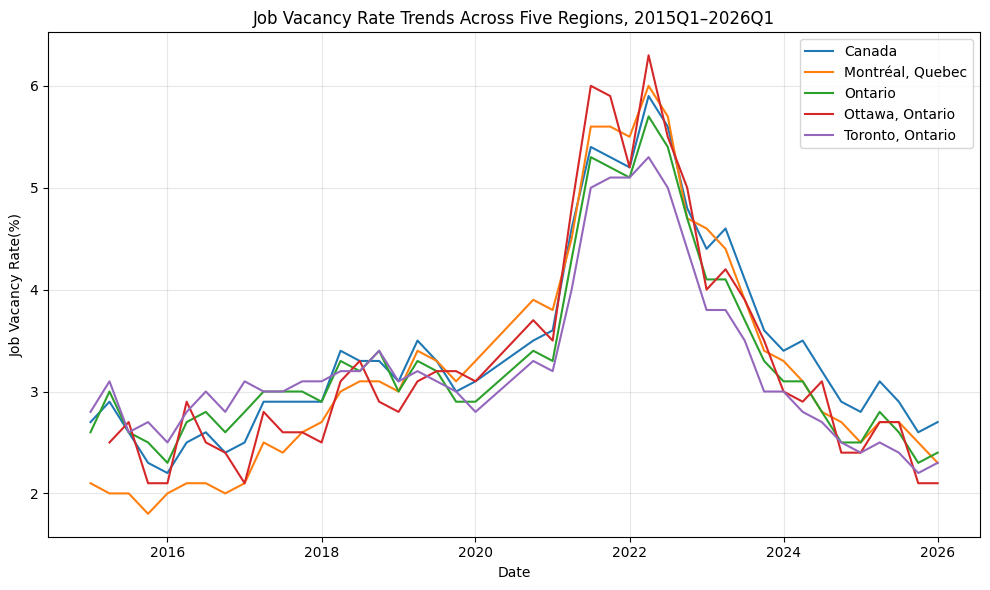

In [244]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for region in comparison_wide_df['GEO'].unique():

  region_df = (
      comparison_wide_df.loc[
          comparison_wide_df['GEO'] == region
  ]
  .sort_values('DATE')
  )

  plt.plot(
      region_df['DATE'],
      region_df['job_vacancy_rate'],
      label = region
  )

plt.xlabel('Date')
plt.ylabel('Job Vacancy Rate(%)')
plt.title('Job Vacancy Rate Trends Across Five Regions, 2015Q1–2026Q1')
plt.legend()

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

#### Key Finding

The five regions followed a broadly similar pattern, with vacancy rates rising sharply around 2021–2022 and declining afterward. Ottawa reached the highest peak among the selected regions in 2022Q2.

### 9.2 Average Offered Hourly Wage Trends Across Five Regions, 2015Q1–2026Q1

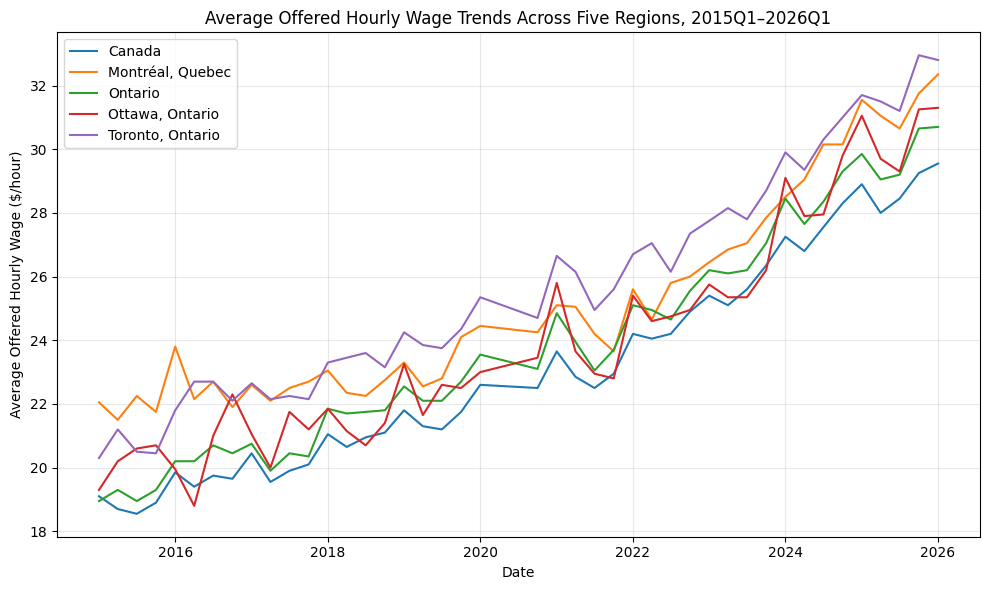

In [245]:
plt.figure(figsize=(10,6))

for region in comparison_wide_df['GEO'].unique():

  region_df = (
      comparison_wide_df.loc[
          comparison_wide_df['GEO'] == region
      ]
      .sort_values('DATE')
  )

  plt.plot(
      region_df['DATE'],
      region_df['average_offered_hourly_wage'],
      label = region
  )

plt.xlabel('Date')
plt.ylabel("Average Offered Hourly Wage ($/hour)")
plt.title("Average Offered Hourly Wage Trends Across Five Regions, 2015Q1–2026Q1")
plt.legend()

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

#### Key Finding

Average offered hourly wages increased across all five regions over the study period. Toronto recorded the highest wage in 2026Q1, while Ottawa showed the largest percentage increase from 2015Q1 to 2026Q1.

> Note: Wage values are nominal and are not adjusted for inflation.

## 10. Key Findings and Limitations

- Ottawa recorded the highest historical job vacancy rate among the five selected regions, reaching 6.3% in 2022Q2.
- Ontario, Ottawa, and Toronto experienced declines in job vacancy rates from their earliest available observations to 2026Q1, while Canada remained unchanged and Montréal increased.
- Toronto had the highest average offered hourly wage in 2026Q1 at $32.80 per hour.
- Toronto recorded the largest absolute wage increase, while Ottawa recorded the largest percentage increase.
- Wage values are nominal and are not adjusted for inflation.